# Olist E-Commerce Business Analysis

## Objective

This notebook analyzes the Olist e-commerce dataset using the curated
dbt models in BigQuery.

The analysis focuses on:

- Overall sales and order performance
- Revenue trends over time
- Customer behavior
- Product performance
- Seller performance
- Payment behavior
- Business insights and recommendations


In [ ]:
# 📦 Install project dependencies
#!pip install -r ../requirements.txt



  Using cached dbt_adapters-1.24.5-py3-none-any.whl.metadata (4.6 kB)
  Using cached altair-6.2.2-py3-none-any.whl.metadata (11 kB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.6.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached uvicorn-0.52.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached httptools-0.8.0-cp311-cp311-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (3.5 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-manylinux2014_x86_64.whl.metadata (44 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydata_google_auth-1.9.1-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl.metadata (11 kB)
  Using cached oauthlib-3.3.1-py3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
PROJECT_ID = "hale-badge-505304-j8"
DATASET = "olist_dataset_mod2"

client = bigquery.Client(project=PROJECT_ID)

def run_query(query):
    return client.query(query).to_dataframe()


In [3]:
query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET}.fact_orders`
"""

fact_orders = run_query(query)

fact_orders.head()


/home/mythili/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,customer_id,order_date,item_count,total_item_value,total_freight_value,total_payment_value
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,2016-09-15 12:16:38+00:00,3,134.97,8.49,0.00
1,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,2016-10-03 16:56:50+00:00,1,21.90,17.19,39.09
2,c4b41c36dd589e901f6879f25a74ec1d,4bb880cac21c7a9e1371ab1ebd601706,2016-10-04 12:53:17+00:00,1,9.90,8.72,18.62
3,a8c3f65a43b2e956cbfca10db4300853,c2c97a4df7be5639a8976ed8b8516e81,2016-10-04 23:39:01+00:00,1,179.90,16.37,196.27
4,79ffdd52a918bbe867895a4b183d6457,f9808148a262b51d20e2d777eee6676c,2016-10-04 12:06:11+00:00,1,299.99,19.01,319.00


In [4]:
query = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET}.fact_payments`
"""

fact_payments = run_query(query)

fact_payments.head()


/home/mythili/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,customer_id,payment_type,payment_value,payment_installments
0,330a8410950e2c8bd89631999a37b2c9,d372561ad1022927871150461a0a85ca,credit_card,147.55,12
1,142c8688b5b13e21ac5a448a1688b9d7,96c6d161a734e063fba237c7d58f75d6,credit_card,327.50,12
2,25e4af6ebff2dfb6213c8cc7e36ecbed,921df0e199c57f4fd686b8a141fb9b86,credit_card,246.55,12
3,5629fdbbd11b9755743ba8b8f517f8cc,410487a17df8bb033e4173a7ab925f66,credit_card,113.46,11
4,e70564a3b448dd6f6d5ca53b0f8222b1,3e2f92a3270a9218d23d86930d081605,credit_card,144.03,12


In [7]:
print("Fact Orders Shape:", fact_orders.shape)
print("Fact Payments Shape:", fact_payments.shape)

display(fact_orders.head())
display(fact_payments.head())


Fact Orders Shape: (98200, 7)
Fact Payments Shape: (102566, 5)


,order_id,customer_id,order_date,item_count,total_item_value,total_freight_value,total_payment_value
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,2016-09-15 12:16:38+00:00,3,134.97,8.49,0.00
1,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,2016-10-03 16:56:50+00:00,1,21.90,17.19,39.09
2,c4b41c36dd589e901f6879f25a74ec1d,4bb880cac21c7a9e1371ab1ebd601706,2016-10-04 12:53:17+00:00,1,9.90,8.72,18.62
3,a8c3f65a43b2e956cbfca10db4300853,c2c97a4df7be5639a8976ed8b8516e81,2016-10-04 23:39:01+00:00,1,179.90,16.37,196.27
4,79ffdd52a918bbe867895a4b183d6457,f9808148a262b51d20e2d777eee6676c,2016-10-04 12:06:11+00:00,1,299.99,19.01,319.00


,order_id,customer_id,payment_type,payment_value,payment_installments
0,330a8410950e2c8bd89631999a37b2c9,d372561ad1022927871150461a0a85ca,credit_card,147.55,12
1,142c8688b5b13e21ac5a448a1688b9d7,96c6d161a734e063fba237c7d58f75d6,credit_card,327.50,12
2,25e4af6ebff2dfb6213c8cc7e36ecbed,921df0e199c57f4fd686b8a141fb9b86,credit_card,246.55,12
3,5629fdbbd11b9755743ba8b8f517f8cc,410487a17df8bb033e4173a7ab925f66,credit_card,113.46,11
4,e70564a3b448dd6f6d5ca53b0f8222b1,3e2f92a3270a9218d23d86930d081605,credit_card,144.03,12


In [8]:
total_orders = fact_orders["order_id"].nunique()

total_customers = fact_orders["customer_id"].nunique()

total_revenue = fact_orders["total_item_value"].sum()

total_freight = fact_orders["total_freight_value"].sum()

total_payments = fact_orders["total_payment_value"].sum()

average_order_value = total_revenue / total_orders

print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Freight: ${total_freight:,.2f}")
print(f"Total Payments: ${total_payments:,.2f}")
print(f"Average Order Value: ${average_order_value:,.2f}")


Total Orders: 98,200
Total Customers: 98,200
Total Revenue: $13,494,191.14
Total Freight: $2,241,094.81
Total Payments: $15,738,207.83
Average Order Value: $137.42


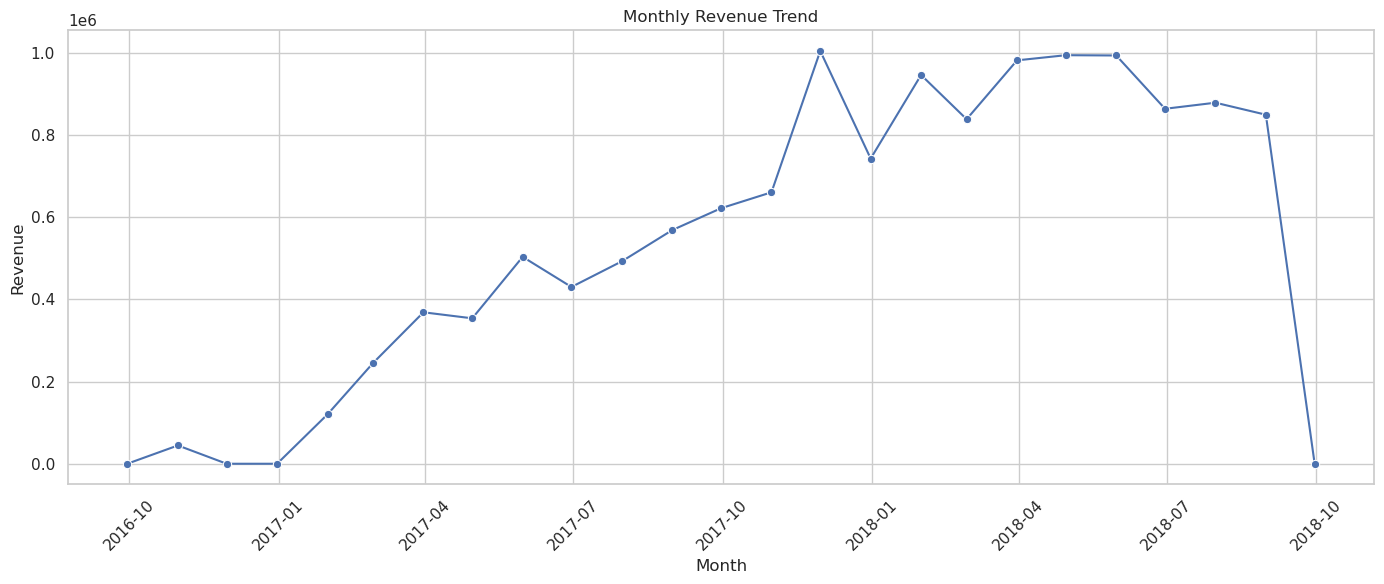

In [9]:
fact_orders["order_date"] = pd.to_datetime(
    fact_orders["order_date"]
)

monthly_sales = (
    fact_orders
    .set_index("order_date")
    .resample("ME")["total_item_value"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="order_date",
    y="total_item_value",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


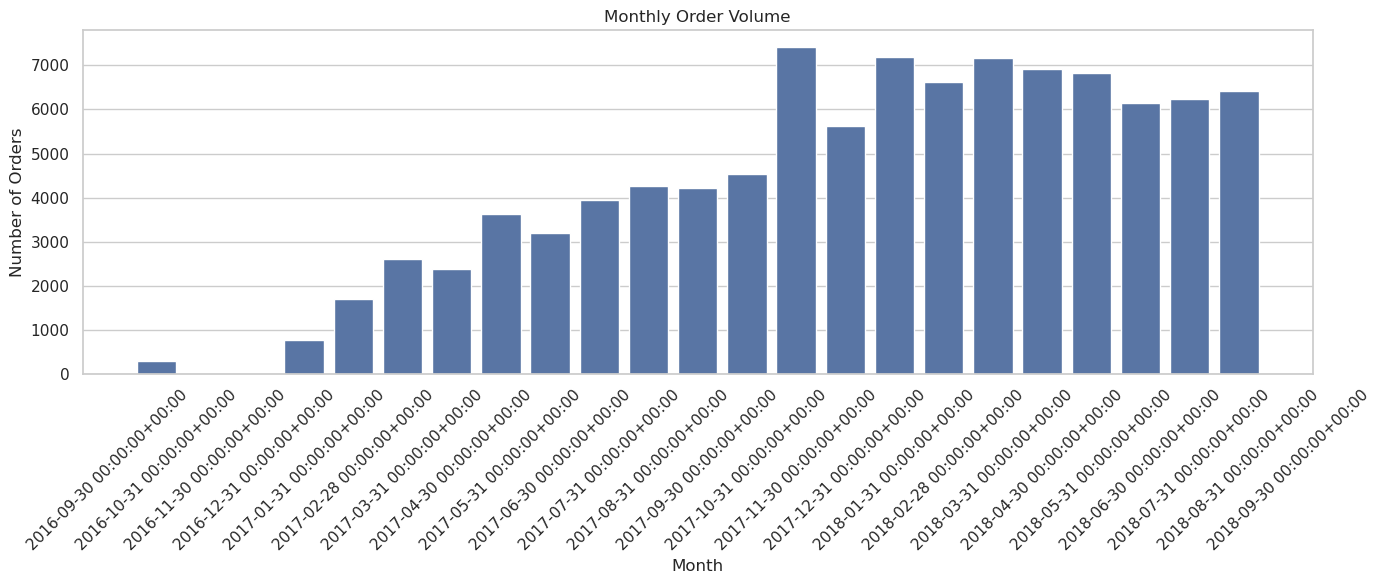

In [10]:
monthly_orders = (
    fact_orders
    .set_index("order_date")
    .resample("ME")["order_id"]
    .nunique()
    .reset_index(name="orders")
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=monthly_orders,
    x="order_date",
    y="orders"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


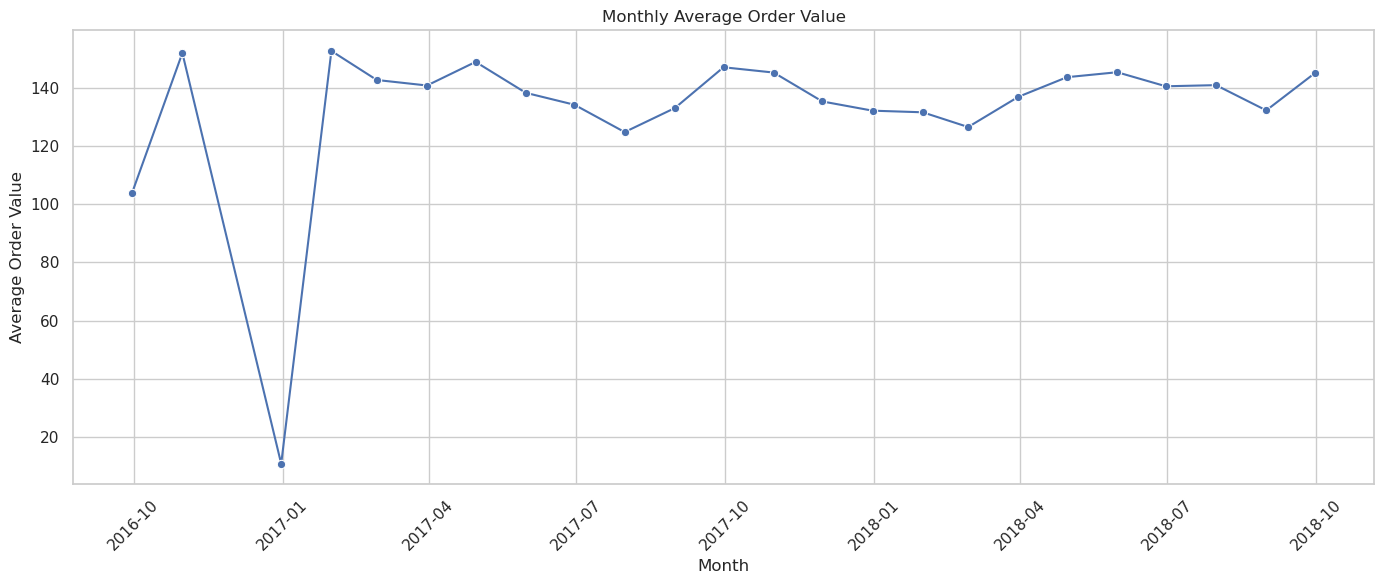

In [11]:
monthly_aov = (
    fact_orders
    .set_index("order_date")
    .resample("ME")
    .agg(
        revenue=("total_item_value", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_aov["aov"] = (
    monthly_aov["revenue"] /
    monthly_aov["orders"]
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_aov,
    x="order_date",
    y="aov",
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
customer_sales = (
    fact_orders
    .groupby("customer_id")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("total_item_value", "sum")
    )
    .reset_index()
)

customer_sales.head()


,customer_id,orders,revenue
0,00012a2ce6f8dcda20d059ce98491703,1,89.80
1,000161a058600d5901f007fab4c27140,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99
3,0002414f95344307404f0ace7a26f1d5,1,149.90
4,000379cdec625522490c315e70c7a9fb,1,93.00


In [13]:
top_customers = (
    customer_sales
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_customers


,customer_id,orders,revenue
8447,1617b1357756262bfa56ab541c47bc16,1,13440.0
90862,ec5b2ba62e574342386871631fafd3fc,1,7160.0
76586,c6e2731c5b391845f6800c97401a43a9,1,6735.0
93950,f48d464a0baaea338cb25f816991ab1f,1,6729.0
24503,3fd6777bbce08a352fddd04e4a7cc8f6,1,6499.0
2042,05455dfa7cd02f13d132aa7a6a9729c6,1,5934.6
85849,df55c14d1476a9a3467f131269c2477f,1,4799.0
14122,24bbf5fd2f2e1b359ee7de94defc4a15,1,4690.0
23673,3d979689f636322c62418b6346b1c6d2,1,4590.0
78742,cc803a2c412833101651d3f90ca7de24,1,4400.0


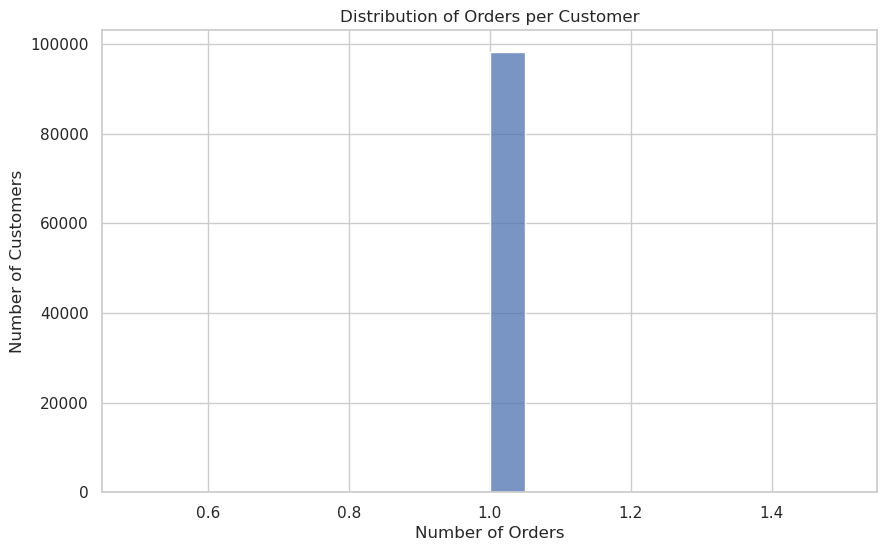

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_sales["orders"],
    bins=20,
    kde=False
)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()


In [15]:
query = f"""
SELECT
    oi.product_id,
    SUM(oi.price) AS revenue,
    SUM(oi.freight_value) AS freight,
    COUNT(*) AS units_sold
FROM `{PROJECT_ID}.{DATASET}.olist_order_items` oi
GROUP BY oi.product_id
ORDER BY revenue DESC
"""

product_sales = run_query(query)

product_sales.head(10)


/home/mythili/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,product_id,revenue,freight,units_sold
0,bb50f2e236e5eea0100680137654686c,63885.00,3721.10,195
1,6cdd53843498f92890544667809f1595,54730.20,4363.79,156
2,d6160fb7873f184099d9bc95e30376af,48899.34,1426.84,35
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,13761.52,343
4,99a4788cb24856965c36a24e339b6058,43025.56,8046.04,488
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,7129.62,274
6,25c38557cf793876c5abdd5931f922db,38907.32,1404.63,38
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,3991.91,63
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,2274.51,323
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,7211.86,527


In [16]:
query = f"""
SELECT
    oi.seller_id,
    COUNT(DISTINCT oi.order_id) AS orders,
    COUNT(*) AS items_sold,
    SUM(oi.price) AS revenue
FROM `{PROJECT_ID}.{DATASET}.olist_order_items` oi
GROUP BY oi.seller_id
ORDER BY revenue DESC
"""

seller_sales = run_query(query)

seller_sales.head(10)


/home/mythili/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,seller_id,orders,items_sold,revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63
1,53243585a1d6dc2643021fd1853d8905,358,410,222776.05
2,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55
9,955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70


In [17]:
payment_analysis = (
    fact_payments
    .groupby("payment_type")
    .agg(
        transactions=("payment_type", "count"),
        revenue=("payment_value", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

payment_analysis


,payment_type,transactions,revenue
1,credit_card,75900,12349288.82
0,boleto,19537,2826626.86
3,voucher,5613,349874.40
2,debit_card,1516,212417.75


In [31]:
#If you want to launch Streamlit from a notebook cell, prefix the command with ! so it’s treated as a shell command
#!streamlit run ../app.py


2026-09-08 17:40:49.889 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.18.209.9:8501

  Help agents write better Streamlit apps?
  Install the official Streamlit skills by running streamlit skills in your terminal.

  Detected WSL. Using poll-based file watching for better compatibility. To force watchdog, set server.fileWatcherType = "watchdog".
gio: http://localhost:8501: Operation not supported
/home/mythili/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
2026-09-08 17:42:14.925 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-09-08 17:42:15.022 Please replace `us

# Key Business Insights

## Sales Performance

- Identify the months with the highest and lowest revenue.
- Compare order growth with revenue growth.
- Monitor changes in average order value.

## Customer Behavior

- Identify the proportion of customers with repeat purchases.
- Identify high-value customers.
- Evaluate customer order frequency.

## Product Performance

- Identify the highest-revenue products.
- Identify products with high sales volume.
- Compare product revenue against freight cost.

## Seller Performance

- Identify top sellers by revenue.
- Compare seller order volume and revenue.
- Identify sellers with high sales concentration.

## Payment Behavior

- Identify the most frequently used payment methods.
- Compare payment methods by total transaction value.

## Recommendations

Use the findings above to propose:

1. Customer retention strategies.
2. Product promotion opportunities.
3. Seller performance improvements.
4. Payment experience optimization.
5. Revenue growth opportunities.
